In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset_amb.mat to dataset_amb.mat
Saving dataset_elec.mat to dataset_elec.mat


In [21]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

#Load Data
amb = scipy.io.loadmat('dataset_amb.mat')
elec = scipy.io.loadmat('dataset_elec.mat')

df = pd.DataFrame({
    'irr': amb['irr'].flatten(), 'pvt': amb['pvt'].flatten(),
    'label': amb['f_nv'].flatten(),
    'idc1': elec['idc1'].flatten(), 'idc2': elec['idc2'].flatten(),
    'vdc1': elec['vdc1'].flatten(), 'vdc2': elec['vdc2'].flatten()
})

Timestamp Generation & Day Splitting
df['timestamp'] = pd.date_range(start='2024-01-01', periods=len(df), freq='1S')

days = [group.reset_index(drop=True) for _, group in df.groupby(df['timestamp'].dt.date)]

#Feature Engineering
df['p_total'] = (df['vdc1'] * df['idc1']) + (df['vdc2'] * df['idc2'])
df['mismatch'] = (df['vdc1']*df['idc1'] - df['vdc2']*df['idc2']).abs() / (df['p_total'] + 1e-6)
df['irr_std'] = df['irr'].rolling(window=50, center=True).std()
df['p_std'] = df['p_total'].rolling(window=50, center=True).std()

#Theoretical Expected Power (Estimated from clear-sky periods)
k_peak = df.loc[df['label']==0, 'p_total'].max() / df.loc[df['label']==0, 'irr'].max()
df['p_expected'] = k_peak * df['irr'] * (1 - 0.004 * (df['pvt'] - 25))

df = df.dropna().reset_index(drop=True)

/tmp/ipython-input-3004620627.py:19: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['timestamp'] = pd.date_range(start='2024-01-01', periods=len(df), freq='1S')


In [28]:
#ML-TRaining 1

X_days_to_train = 10

# Recreate 'days' list from the updated 'df' to ensure all engineered features are included.
days = [group.reset_index(drop=True) for _, group in df.groupby(df['timestamp'].dt.date)]

#Train filterig
train_data_list = days[:X_days_to_train]
train_df = pd.concat(train_data_list)
train_df = train_df[train_df['label'] == 4]

#Define features and target
features = ['irr', 'pvt', 'vdc1', 'vdc2', 'idc1', 'idc2', 'p_total', 'mismatch', 'irr_std', 'p_std']
X_train = train_df[features]
y_train = train_df['shading_type']

#Fit the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"Model trained successfully on {X_days_to_train} days.")

Model trained successfully on 10 days.


In [22]:
#Machine Learning 2
# Define Shading Targets: 0 = Static (Normal), 1 = Dynamic (Random/Cloud)
shading_mask = (df['label'] == 4)
threshold = df.loc[shading_mask, 'irr_std'].median()
df['shading_type'] = -1
df.loc[shading_mask & (df['irr_std'] <= threshold), 'shading_type'] = 0
df.loc[shading_mask & (df['irr_std'] > threshold), 'shading_type'] = 1

# Train on a slice of days
features = ['irr', 'pvt', 'vdc1', 'vdc2', 'idc1', 'idc2', 'p_total', 'mismatch', 'irr_std', 'p_std']
train_df = df[df['label'] == 4].iloc[:20000] # Training sample
X_train, y_train = train_df[features], train_df['shading_type']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
def plot_day_ml(day_df, day_num):
    # Predict only for samples where label is 4
    shading_indices = day_df[day_df['label'] == 4].index
    if not shading_indices.empty:
        day_df.loc[shading_indices, 'pred'] = model.predict(day_df.loc[shading_indices, features])

    plt.figure(figsize=(12, 6))
    plt.plot(day_df['timestamp'], day_df['irr'], color='gold', label='Irradiance', alpha=0.3)
    plt.plot(day_df['timestamp'], day_df['p_expected'], color='blue', linestyle='--', label='Expected Power')
    plt.plot(day_df['timestamp'], day_df['p_total'], color='red', label='Actual Power', linewidth=1.5)

    # Logic to find blocks for shading highlights
    if not shading_indices.empty:
        # Simplified block detection for plotting
        diffs = np.diff(shading_indices)
        breaks = np.where(diffs > 1)[0]
        starts = [shading_indices[0]] + shading_indices[breaks + 1].tolist()
        ends = shading_indices[breaks].tolist() + [shading_indices[-1]]

        for s, e in zip(starts, ends):
            block = day_df.loc[s:e]
            pred_type = block['pred'].mode()[0]
            color = 'cyan' if pred_type == 1 else 'orange'
            plt.axvspan(day_df.loc[s, 'timestamp'], day_df.loc[e, 'timestamp'], color=color, alpha=0.3)

    plt.title(f"Day {day_num} Diagnosis: Orange=Static Shadow, Cyan=Cloud")
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

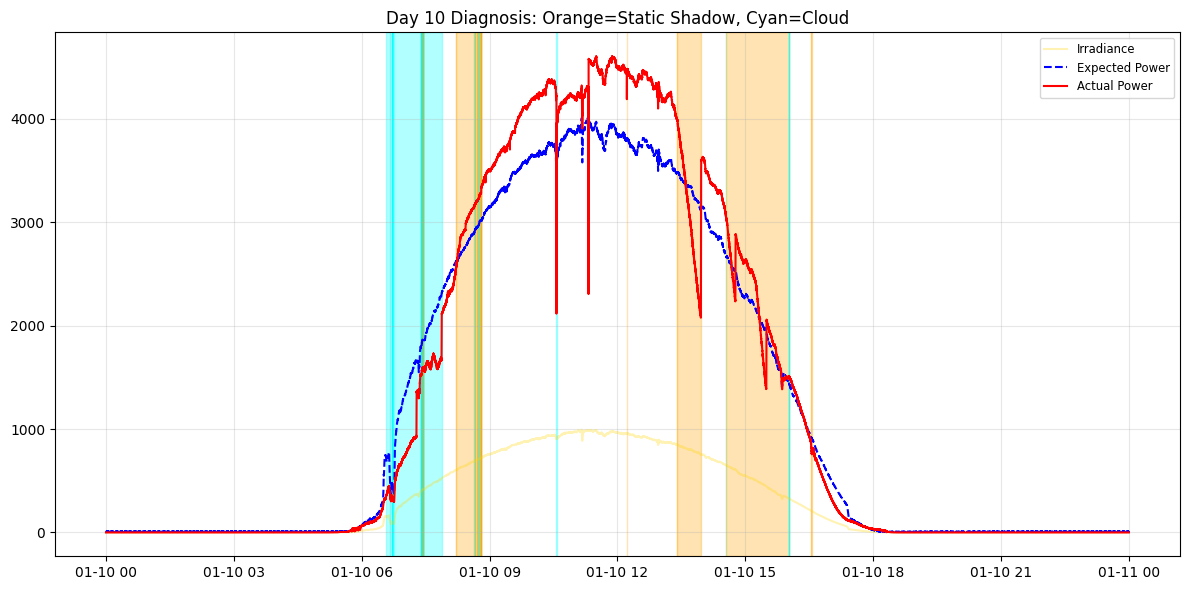

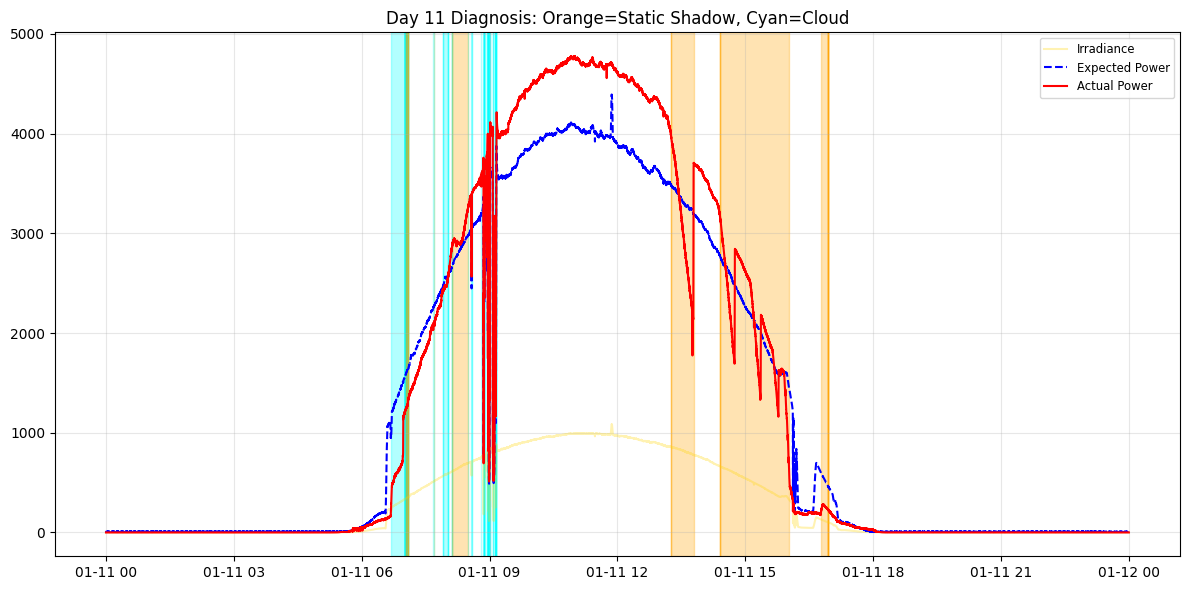

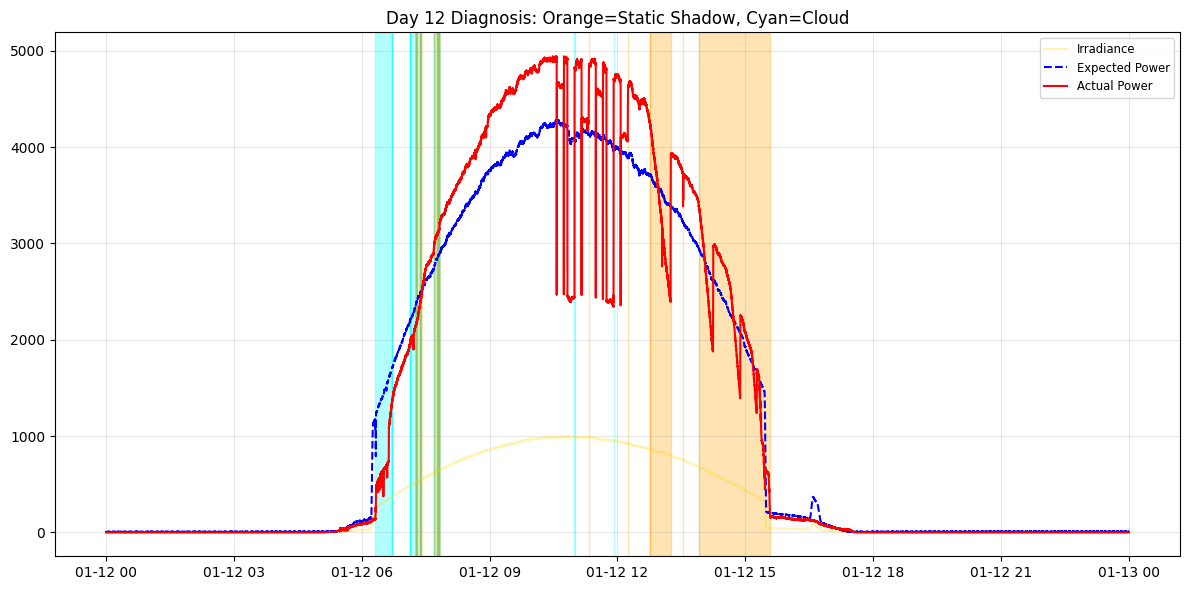

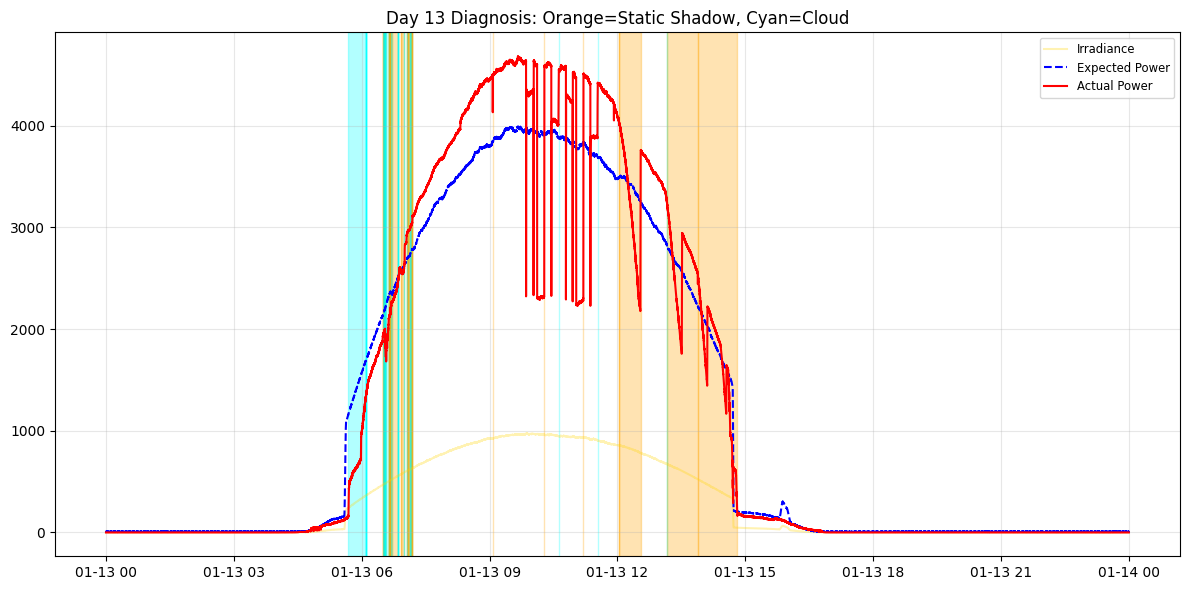

In [31]:
plot_day_ml(final_days[9], 10)
plot_day_ml(final_days[10], 11)
plot_day_ml(final_days[11], 12)
plot_day_ml(final_days[12], 13)